In [1]:
# import statements
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import pandas as pd

from scipy.optimize import curve_fit
import scipy.spatial

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA

In [2]:
# read datasets
soil_temp = pd.read_csv("dataset_Wigand_National_Park_Central_Alaska\\monthly_soil_temp.csv")
snow_depth = pd.read_csv("dataset_Wigand_National_Park_Central_Alaska\\monthly_snow_depth.csv")
air_temp = pd.read_csv("dataset_Wigand_National_Park_Central_Alaska\\monthly_air_temp.csv")
water_prec = pd.read_csv('dataset_Wigand_National_Park_Central_Alaska\\monthly_water_precipation.csv')
solar_radi = pd.read_csv('dataset_Wigand_National_Park_Central_Alaska\\monthly_solar_radiation.csv')

# rename columns to define columns more clearly
soil_temp = soil_temp.rename(columns={'Average (°F)': 'Average (°F) Soil Temperature'})
air_temp = air_temp.rename(columns={'Average (°F)': 'Average (°F) Air Temperature'})
water_prec = water_prec.rename(columns={'Average (in)': 'Average (in) Water Precipation'})
snow_depth = snow_depth.rename(columns={'Average (in)': 'Average (in) Snow Depth'})

# combine data into one dataframe
full_df = pd.concat([soil_temp[['Start of Interval (UTC-08:00)', 'Average (°F) Soil Temperature']],
                     snow_depth['Average (in) Snow Depth'], air_temp['Average (°F) Air Temperature'],
                     water_prec['Average (in) Water Precipation'],
                     solar_radi['Average (W/m^2)']
                     ], axis=1)

# drop all rows that contain NaN value(s)
clean_df = full_df.dropna()
clean_df

,Start of Interval (UTC-08:00),Average (°F) Soil Temperature,Average (in) Snow Depth,Average (°F) Air Temperature,Average (in) Water Precipation,Average (W/m^2)
1,2013-09-01 00:00:00,35.283542,1.061506,38.013375,0.002597,82.985099
2,2013-10-01 00:00:00,31.745793,1.411058,32.570349,0.001237,46.321038
3,2013-11-01 00:00:00,29.733333,3.152507,10.181750,0.000500,11.162500
4,2013-12-01 00:00:00,25.783602,6.579368,2.205672,0.000161,3.283602
5,2014-01-01 00:00:00,24.517473,4.675539,16.544073,0.000202,9.420699
...,...,...,...,...,...,...
128,2024-04-01 00:00:00,30.800403,9.632872,31.026264,0.000139,183.007508
130,2024-06-01 00:00:00,43.118083,1.903225,58.579625,0.002097,237.333626
137,2025-01-01 00:00:00,28.631116,7.658630,12.810188,0.000551,7.562282
138,2025-02-01 00:00:00,25.600000,6.976920,7.720046,0.000030,39.641704


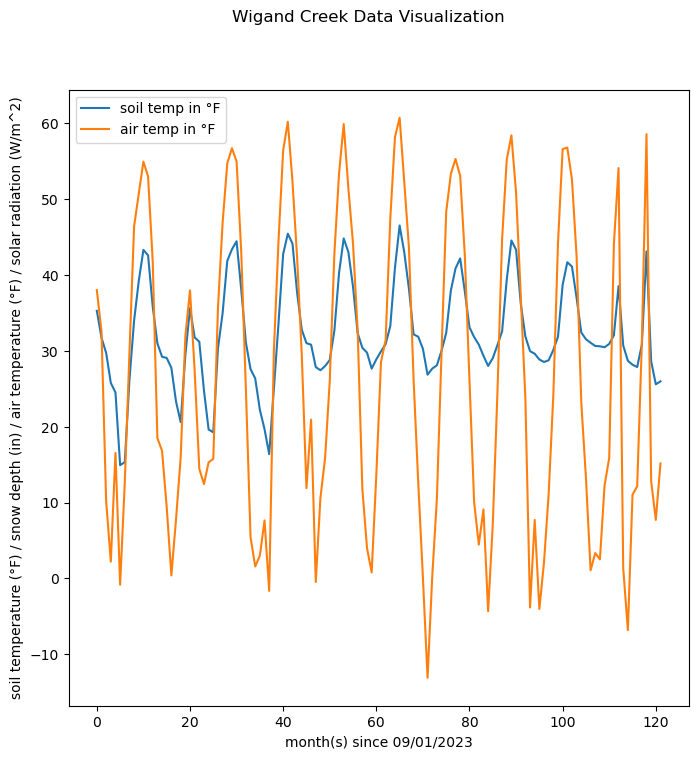

In [3]:
# create new figure
fig, ax = plt.subplots(figsize=(8, 8))

# set time variable in pure numerical values
dates = [num for num in range(len(clean_df['Start of Interval (UTC-08:00)']))]

# plot different column values in one plot to show variable relationships
ax.plot(dates, clean_df['Average (°F) Soil Temperature'], label='soil temp in °F')
# ax.plot(dates, clean_df['Average (in) Snow Depth'], label='snow depth in inch')
ax.plot(dates, clean_df['Average (°F) Air Temperature'], label='air temp in °F')

# the 5000 is a scaler constant for water precipation as it contains small values that's difficult to be compared visually
# ax.plot(dates, 5000 * clean_df['Average (in) Water Precipation'], label='water precipation in inch times 5000')
# the 0.3 is a scaler constant for Solar Radiation data as it has significantly big values that's making visual comparison between data difficult
# ax.plot(dates, 0.3 * clean_df['Average (W/m^2)'], label='Solar Radiation in (W/m^2) times 0.3')

# set labels and title and legend
ax.set_xlabel('month(s) since 09/01/2023')
ax.set_ylabel('soil temperature (°F) / snow depth (in) / air temperature (°F) / solar radiation (W/m^2)')
fig.suptitle('Wigand Creek Data Visualization')
ax.legend()


In [4]:
# separate independent variables into one single dataframe for principal component analysis
predictors = clean_df[['Average (in) Snow Depth',
                       'Average (°F) Air Temperature',
                    #    'Average (in) Water Precipation',
                       'Average (W/m^2)'
                       ]]

# perform principal component analysis
scaler = StandardScaler()
df = scaler.fit_transform(predictors)
pca = PCA(n_components=2)
pcas = pca.fit_transform(df)

pca_df = pd.DataFrame(pcas, columns=['PC1', 'PC2'])
pca_df['Average (°F) Soil Temperature'] = clean_df['Average (°F) Soil Temperature']

# fig3, ax = plt.subplots(figsize=(8, 8))

# plot = ax.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Average (°F) Soil Temperature'], cmap='viridis')

# fig.legend()
# # ax.scatter(pca_df['PC1'], pca_df['PC2'])
# fig3.supxlabel('PC1')
# fig3.supylabel('PC2')

# color_bar = fig3.colorbar(plot, ax=ax)
# color_bar.set_label('Soil Temperature (°F)')
total_var = pca.explained_variance_ratio_.sum()

# coeff = np.polyfit(pca_df['PC1'], pca_df['PC2'], 2)

# f = np.poly1d(coeff)
# x = np.linspace(-3, 4, 1000)
# ax.plot(x, f(x))

print(total_var)

0.9590236677430876


Text(0.5, 0.98, 'Principal Component 1 vs Average Soil Temperature')

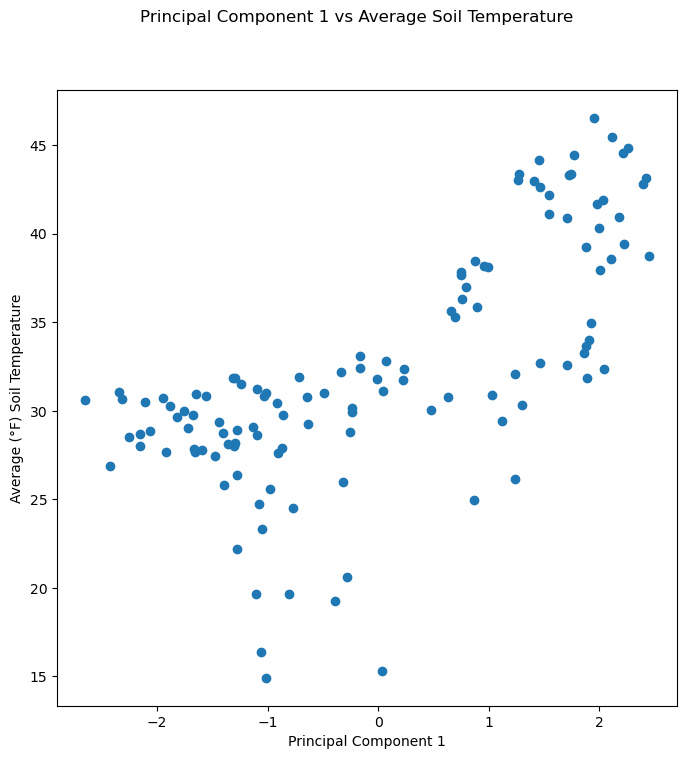

In [5]:
# create figure for comparing first principal compoent and average soil temperature data 
fig4, ax3 = plt.subplots(figsize=(8, 8))

# plot, set labels and title
ax3.scatter(pca_df['PC1'], clean_df['Average (°F) Soil Temperature'])
ax3.set_xlabel('Principal Component 1')
ax3.set_ylabel('Average (°F) Soil Temperature')
fig4.suptitle('Principal Component 1 vs Average Soil Temperature')

# coeff = np.polyfit(pca_df['PC1'], pca_df['Average (°F) Soil Temperature'], 2)
# f2 = np.poly1d(coeff)
# ax3.plot(x, f2(x))

Text(0.5, 0.98, 'Individual Variable Correlation to Soil Temperature')

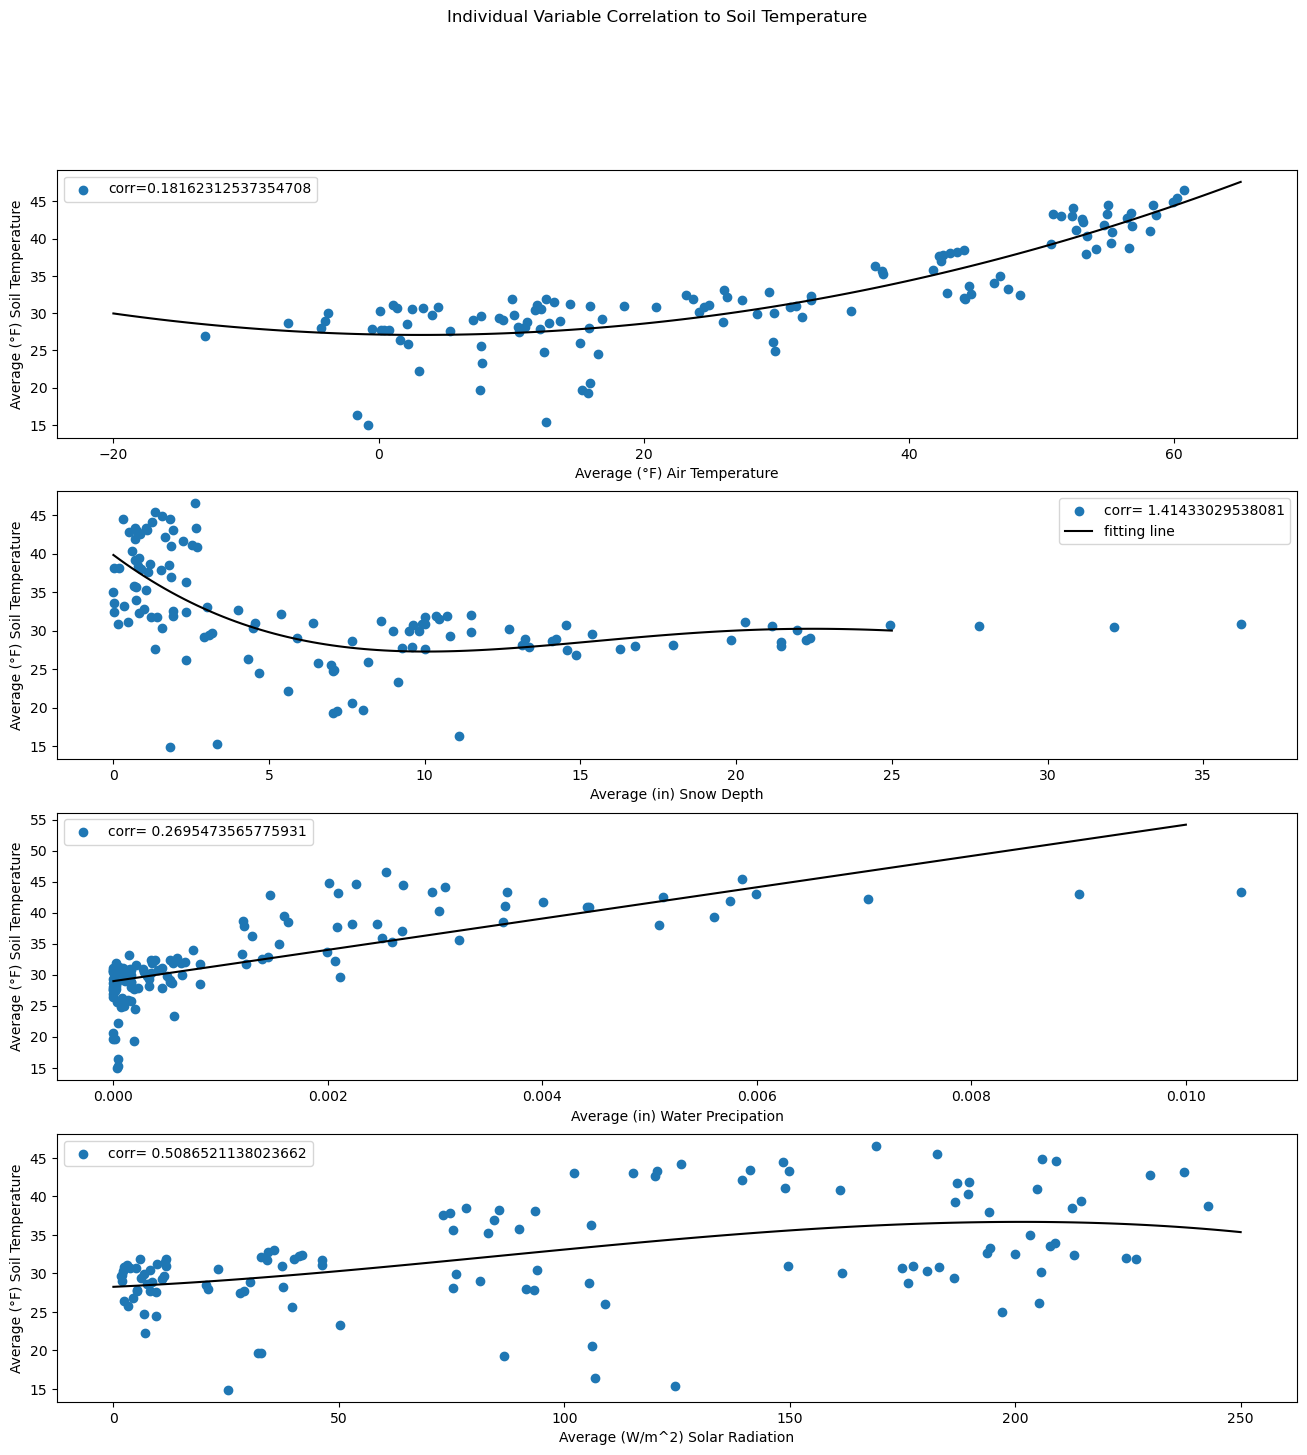

In [6]:
# construct a new plot
fig2, axes = plt.subplots(4, figsize=(16, 16))

# find distance correlation of variable Average Air Temperature and target variable Average Soil Temperature
corr0 = scipy.spatial.distance.correlation(clean_df['Average (°F) Air Temperature'],
                                           clean_df['Average (°F) Soil Temperature']
                                           )

# plot data points of Average Air Temperature and target variable Average Soil Temperature
axes[0].scatter(clean_df['Average (°F) Air Temperature'], clean_df['Average (°F) Soil Temperature'], label="corr=" + str(corr0))
axes[0].set_xlabel('Average (°F) Air Temperature')
axes[0].set_ylabel('Average (°F) Soil Temperature')

# find fitting line to depict any potential relationship between variable Air Temperature and target variable Average Soil Temperature
coeff = np.polyfit(clean_df['Average (°F) Air Temperature'], clean_df['Average (°F) Soil Temperature'], 2)
f2 = np.poly1d(coeff)
# plot fitting line
x = np.linspace(-20, 65, len(clean_df['Average (°F) Soil Temperature']))
axes[0].plot(x, f2(x), c='k')

# find distance correlation of variable Average Snow Depth and target variable Average Soil Temperature
corr1 = scipy.spatial.distance.correlation(clean_df['Average (in) Snow Depth'],
                                           clean_df['Average (°F) Soil Temperature']
                                           )

# plot data points of Average Snow Depth and target variable Average Soil Temperature
axes[1].scatter(clean_df['Average (in) Snow Depth'], clean_df['Average (°F) Soil Temperature'], label='corr= ' + str(corr1))
axes[1].set_xlabel('Average (in) Snow Depth')
axes[1].set_ylabel('Average (°F) Soil Temperature')

# find fitting line to depict any potential relationship between Average Snow Depth and target variable Average Soil Temperature
coeff = np.polyfit(clean_df['Average (in) Snow Depth'], clean_df['Average (°F) Soil Temperature'], 5)
f3 = np.poly1d(coeff)
# plot fitting line
x = np.linspace(0, 25, len(clean_df['Average (°F) Soil Temperature']))
axes[1].plot(x, f3(x), c='k', label='fitting line')

# find distance correlation of variable Average Water Precipitation and target variable Average Soil Temperature
corr2 = scipy.spatial.distance.correlation(clean_df['Average (in) Water Precipation'],
                                           clean_df['Average (°F) Soil Temperature']
                                           )

# plot data points of Average Water Pirecipitation and target variable Average Soil Temperature
axes[2].scatter(clean_df['Average (in) Water Precipation'], clean_df['Average (°F) Soil Temperature'], label='corr= ' + str(corr2))
axes[2].set_xlabel('Average (in) Water Precipation')
axes[2].set_ylabel('Average (°F) Soil Temperature')

# coeff = np.polyfit(clean_df['Average (in) Water Precipation'], clean_df['Average (°F) Soil Temperature'], 3)
# f4 = np.poly1d(coeff)
# x = np.linspace(0, 0.006, len(clean_df['Average (°F) Soil Temperature']))
# axes[2].plot(x, f4(x), c='k')

# find fitting line to depict any potential relationship between Average Water Precipitation and target variable Average Soil Temperature
exponential = lambda x_space, a, b, c: a * np.exp(b * x_space) + c
init_condi = [5, 4, 0]

params, _ = curve_fit(exponential,
                      clean_df['Average (in) Water Precipation'],
                      clean_df['Average (°F) Soil Temperature'],
                      p0=init_condi
                      )
x_space = np.linspace(0, 0.01, 10000)

# plot fitting line
axes[2].plot(x_space, exponential(x_space, params[0], params[1], params[2]), c='k')
    
# find distance correlation of variable Average Solar Radiation and target variable Average Soil Temperature
corr3 = scipy.spatial.distance.correlation(clean_df['Average (W/m^2)'],
                                           clean_df['Average (°F) Soil Temperature']
                                           )

# plot data points of Average Solar Radiation and target variable Average Soil Temperature
axes[3].scatter(clean_df['Average (W/m^2)'], clean_df['Average (°F) Soil Temperature'], label='corr= ' + str(corr3))
axes[3].set_xlabel('Average (W/m^2) Solar Radiation')
axes[3].set_ylabel('Average (°F) Soil Temperature')

# find fitting line to depict any potential relationship between Average Solar Radiation and target variable Average Soil Temperature
coeff = np.polyfit(clean_df['Average (W/m^2)'], clean_df['Average (°F) Soil Temperature'], 3)
f4 = np.poly1d(coeff)
x = np.linspace(0, 250, len(clean_df['Average (°F) Soil Temperature']))
# plot fitting line
axes[3].plot(x, f4(x), c='k')

# legends and title
axes[0].legend()
axes[1].legend()
axes[2].legend()
axes[3].legend()

fig2.suptitle('Individual Variable Correlation to Soil Temperature')


Text(0, 0.5, 'Average (in) Snow Depth')

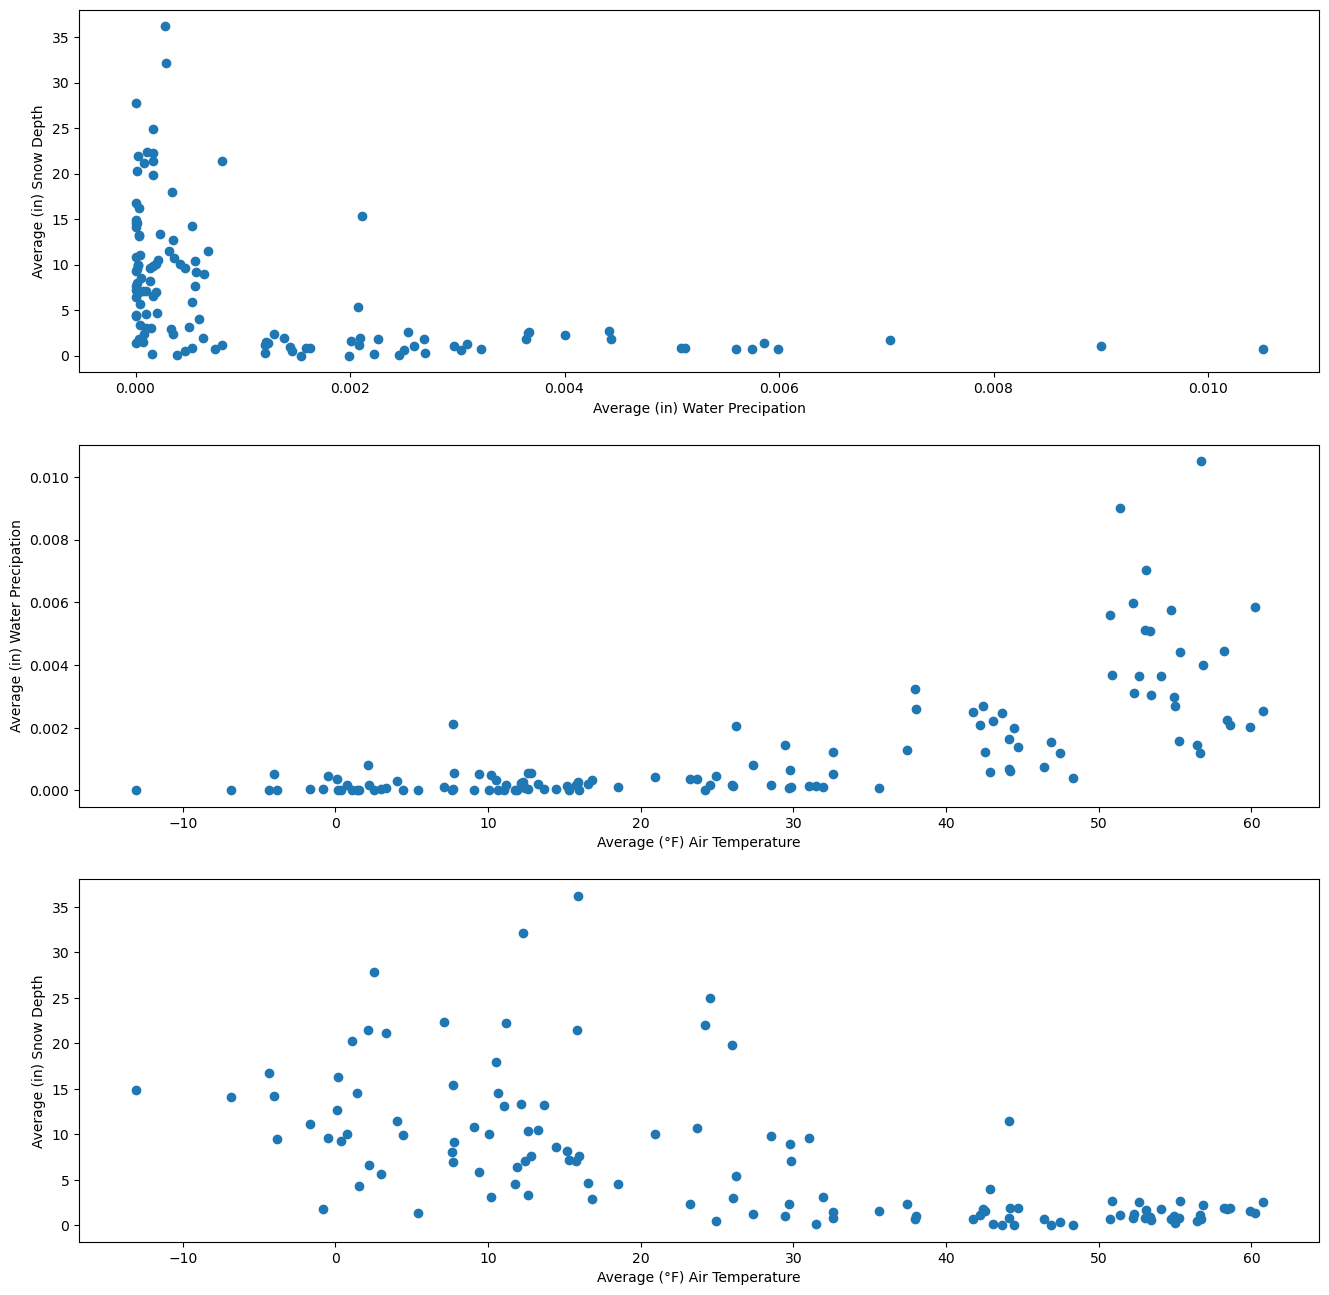

In [7]:
fig3, axes2 = plt.subplots(3, figsize=(16, 16))

axes2[0].scatter(clean_df['Average (in) Water Precipation'], clean_df['Average (in) Snow Depth'])
axes2[0].set_xlabel('Average (in) Water Precipation')
axes2[0].set_ylabel('Average (in) Snow Depth')

# 'Average (°F) Air Temperature'
# 'Average (in) Water Precipation'
axes2[1].scatter(clean_df['Average (°F) Air Temperature'], clean_df['Average (in) Water Precipation'])
axes2[1].set_ylabel('Average (in) Water Precipation')
axes2[1].set_xlabel('Average (°F) Air Temperature')

axes2[2].scatter(clean_df['Average (°F) Air Temperature'], clean_df['Average (in) Snow Depth'])
axes2[2].set_xlabel('Average (°F) Air Temperature')
axes2[2].set_ylabel('Average (in) Snow Depth')


In [8]:
clean_df

,Start of Interval (UTC-08:00),Average (°F) Soil Temperature,Average (in) Snow Depth,Average (°F) Air Temperature,Average (in) Water Precipation,Average (W/m^2)
1,2013-09-01 00:00:00,35.283542,1.061506,38.013375,0.002597,82.985099
2,2013-10-01 00:00:00,31.745793,1.411058,32.570349,0.001237,46.321038
3,2013-11-01 00:00:00,29.733333,3.152507,10.181750,0.000500,11.162500
4,2013-12-01 00:00:00,25.783602,6.579368,2.205672,0.000161,3.283602
5,2014-01-01 00:00:00,24.517473,4.675539,16.544073,0.000202,9.420699
...,...,...,...,...,...,...
128,2024-04-01 00:00:00,30.800403,9.632872,31.026264,0.000139,183.007508
130,2024-06-01 00:00:00,43.118083,1.903225,58.579625,0.002097,237.333626
137,2025-01-01 00:00:00,28.631116,7.658630,12.810188,0.000551,7.562282
138,2025-02-01 00:00:00,25.600000,6.976920,7.720046,0.000030,39.641704


In [9]:
# set predictors for neural network modeling
x_data = clean_df[['Average (°F) Air Temperature',
                   'Average (in) Snow Depth',
                   'Average (in) Water Precipation',
                   'Average (W/m^2)'
                   ]]

y_data = clean_df['Average (°F) Soil Temperature']

# create predictor data and target data and categorize them into training and test sets, in portions of 60% training data and 40% of test data
x_train, x_test, y_train, y_test = train_test_split(pcas, y_data, train_size = 0.6, random_state=0)

# (StandardScaler object already created in previous code blocks)
# scale data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# create model
model = MLPRegressor(hidden_layer_sizes=(10,), max_iter=500)

# storage lists for storing each train and test accuracy scores for every iteration of neural network modeling result.
train_accuracies = []
test_accuracies = []

# run 200 iteratinos of neural network modeling:

model.fit(x_train_scaled, y_train)

train_accuracy = model.score(x_train_scaled, y_train)
test_accuracy = model.score(x_test, y_test)

train_accuracies.append(train_accuracy)
test_accuracies.append(test_accuracy)

y_pred = model.predict(x_test_scaled)

print(train_accuracies, test_accuracies)



[-15.384268983574092] [-15.297910207675518]


c:\Users\yangs\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
